In [20]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import simps
import sys

sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8' 
dec = 'greek8'

In [21]:
raw_data = pd.read_csv('../data/GR_WNV_cases_2023.csv', encoding = enc)
raw_data.head(5)

,Έτος,Ημ/νία έναρξης συμπτωμάτων,Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Αριθμός ασθενών ΜΕ εκδηλώσεις από το ΚΝΣ,Αριθμός ασθενών ΧΩΡΙΣ εκδηλώσεις από το ΚΝΣ,Συνολικός αριθμός ασθενών
0,2023,18-07-23,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,1,0,1
1,2023,25-07-23,Θεσσαλίας,Καρδίτσας,Καρδίτσας,1,0,1
2,2023,25-07-23,Ανατολικής Μακεδονίας και Θράκης,Καβάλας,Νέστου,0,1,1
3,2023,01-08-23,Ανατολικής Μακεδονίας και Θράκης,Καβάλας,Νέστου,1,0,1
4,2023,01-08-23,Θεσσαλίας,Καρδίτσας,Καρδίτσας,1,0,1


In [22]:
raw_data.shape

(125, 8)

In [23]:
data = raw_data.set_axis(['year', 'onset of symptoms', 'nuts2', 'nuts3', 'lau1', 'cases_CNS', 'cases_WO_CNS', 'cases'], axis=1, inplace=False)

In [24]:
data.drop(columns = ['cases_CNS', 'cases_WO_CNS'], inplace = True)
data.head(5)

,year,onset of symptoms,nuts2,nuts3,lau1,cases
0,2023,18-07-23,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,1
1,2023,25-07-23,Θεσσαλίας,Καρδίτσας,Καρδίτσας,1
2,2023,25-07-23,Ανατολικής Μακεδονίας και Θράκης,Καβάλας,Νέστου,1
3,2023,01-08-23,Ανατολικής Μακεδονίας και Θράκης,Καβάλας,Νέστου,1
4,2023,01-08-23,Θεσσαλίας,Καρδίτσας,Καρδίτσας,1


In [25]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,year,0.0
1,onset of symptoms,0.0
2,nuts2,0.0
3,nuts3,0.0
4,lau1,0.0
5,cases,0.0


In [26]:
data.shape

(125, 6)

In [27]:
data['onset of symptoms'] = pd.to_datetime(data['onset of symptoms'], dayfirst=True, errors='coerce')

In [28]:
data

,year,onset of symptoms,nuts2,nuts3,lau1,cases
0,2023,2023-07-18,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,1
1,2023,2023-07-25,Θεσσαλίας,Καρδίτσας,Καρδίτσας,1
2,2023,2023-07-25,Ανατολικής Μακεδονίας και Θράκης,Καβάλας,Νέστου,1
3,2023,2023-08-01,Ανατολικής Μακεδονίας και Θράκης,Καβάλας,Νέστου,1
4,2023,2023-08-01,Θεσσαλίας,Καρδίτσας,Καρδίτσας,1
...,...,...,...,...,...,...
120,2023,2023-10-17,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Καλαμαριάς,1
121,2023,2023-10-17,Κεντρικής Μακεδονίας,Ημαθίας,Ηρωικής Πόλεως Νάουσας,1
122,2023,2023-10-17,Δυτικής Ελλάδας,Αχαΐας,Αιγιαλείας,1
123,2023,2023-10-17,Πελοποννήσου,Αργολίδας,Άργους - Μυκηνών,1


<AxesSubplot:>

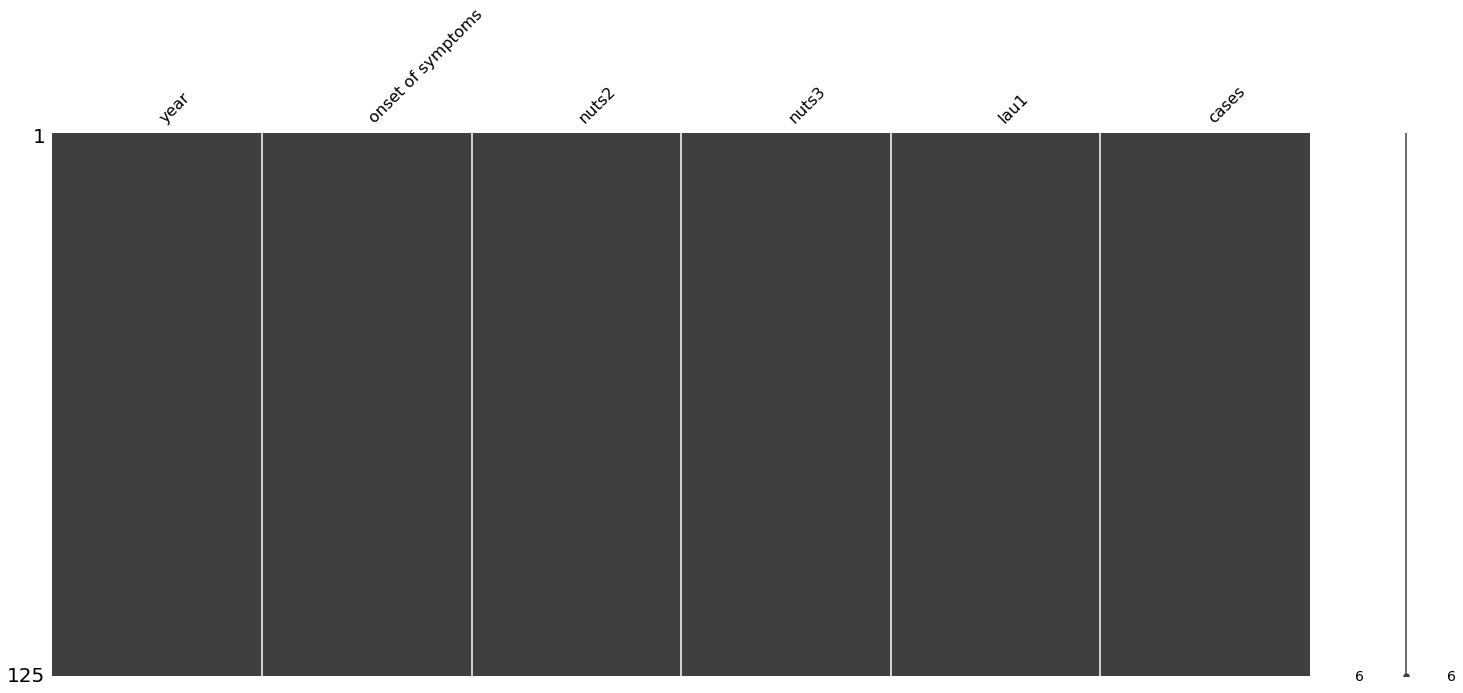

In [29]:
missingno.matrix(data)

In [30]:
process_greek(data, 'nuts2')
process_greek(data, 'nuts3')
process_greek(data, 'lau1')

In [31]:
data

,year,onset of symptoms,nuts2,nuts3,lau1,cases
0,2023,2023-07-18,κεντρικης μακεδονιας,σερρων,ηρακλειας,1
1,2023,2023-07-25,θεσσαλιας,καρδιτσας,καρδιτσας,1
2,2023,2023-07-25,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,1
3,2023,2023-08-01,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,1
4,2023,2023-08-01,θεσσαλιας,καρδιτσας,καρδιτσας,1
...,...,...,...,...,...,...
120,2023,2023-10-17,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,1
121,2023,2023-10-17,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολεως ναουσας,1
122,2023,2023-10-17,δυτικης ελλαδας,αχαιας,αιγιαλειας,1
123,2023,2023-10-17,πελοποννησου,αργολιδας,αργους μυκηνων,1


In [32]:
data['day'] = data['onset of symptoms'].apply(lambda x : x.day)
data['month'] = data['onset of symptoms'].apply(lambda x : x.month)

In [33]:
data

,year,onset of symptoms,nuts2,nuts3,lau1,cases,day,month
0,2023,2023-07-18,κεντρικης μακεδονιας,σερρων,ηρακλειας,1,18,7
1,2023,2023-07-25,θεσσαλιας,καρδιτσας,καρδιτσας,1,25,7
2,2023,2023-07-25,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,1,25,7
3,2023,2023-08-01,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,1,1,8
4,2023,2023-08-01,θεσσαλιας,καρδιτσας,καρδιτσας,1,1,8
...,...,...,...,...,...,...,...,...
120,2023,2023-10-17,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,1,17,10
121,2023,2023-10-17,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολεως ναουσας,1,17,10
122,2023,2023-10-17,δυτικης ελλαδας,αχαιας,αιγιαλειας,1,17,10
123,2023,2023-10-17,πελοποννησου,αργολιδας,αργους μυκηνων,1,17,10


In [34]:
data = data.reindex(columns=['onset of symptoms', 'year', 'month', 'day', 'nuts2', 'nuts3', 'lau1', 'cases'])

In [35]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,cases
0,2023-07-18,2023,7,18,κεντρικης μακεδονιας,σερρων,ηρακλειας,1
1,2023-07-25,2023,7,25,θεσσαλιας,καρδιτσας,καρδιτσας,1
2,2023-07-25,2023,7,25,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,1
3,2023-08-01,2023,8,1,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,1
4,2023-08-01,2023,8,1,θεσσαλιας,καρδιτσας,καρδιτσας,1
...,...,...,...,...,...,...,...,...
120,2023-10-17,2023,10,17,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,1
121,2023-10-17,2023,10,17,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολεως ναουσας,1
122,2023-10-17,2023,10,17,δυτικης ελλαδας,αχαιας,αιγιαλειας,1
123,2023-10-17,2023,10,17,πελοποννησου,αργολιδας,αργους μυκηνων,1


In [36]:
data.to_csv("../data/GR_WNV_cases_2023_processed.csv", encoding = enc, index = False)

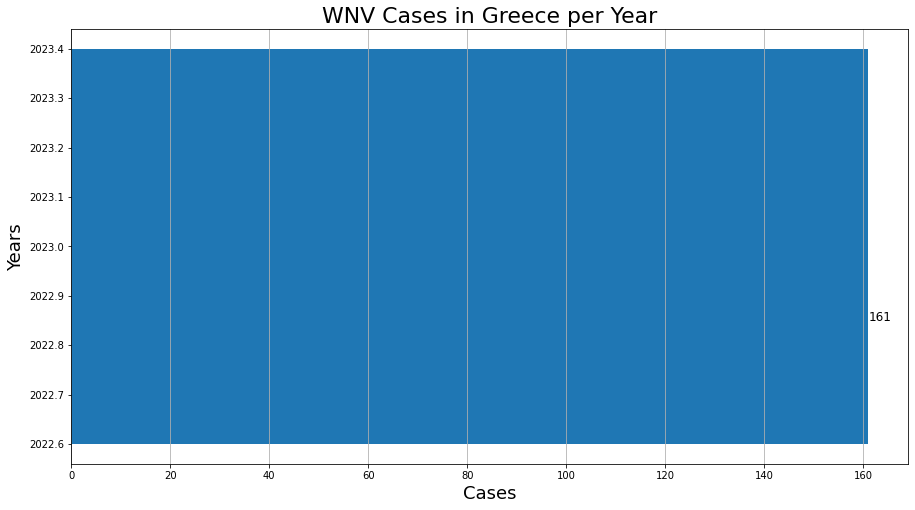

In [37]:
years = 2023
cases = data.cases.sum()

plt.figure(num = None, figsize = (15,8), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
#y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 50), size = 14)
#x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per Year', size = 22)

plt.text(cases+0.15, years-0.15, str(cases), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

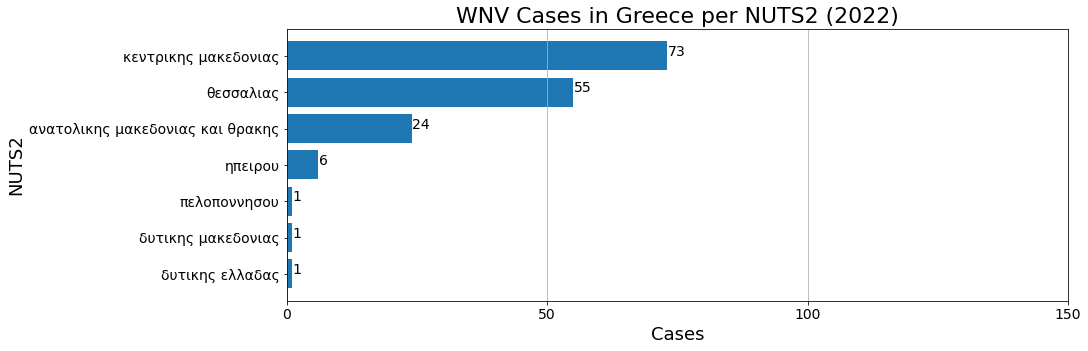

In [19]:
nuts2 = data['nuts2'].drop_duplicates().sort_values().tolist()
cases = [data.query(f"nuts2 == '{nuts2_unit}'").cases.sum() for nuts2_unit in nuts2]

cases, nuts2 = zip(*sorted(zip(cases, nuts2)))

plt.figure(num = None, figsize = (14,5), facecolor='w', edgecolor='b')
plt.barh(nuts2, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 14)
x_t = plt.yticks(nuts2, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per NUTS2 (2022)', size = 22)
for nuts2, case in zip(nuts2,cases):
    plt.text(case+0.15, nuts2, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()
